In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, time, os
from pathlib import Path
from scipy import stats

In [104]:
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [105]:

from sklearn.model_selection import (
    StratifiedKFold, cross_validate, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import (
    roc_auc_score, recall_score, f1_score, precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [106]:
SEED        = 42
TRAIN_GENS  = ['AD14', 'AD15', 'AD16', 'AD17', 'AD18']
TEST_GENS   = ['AD19', 'AD20']
TARGET      = 'retention'
K_CLUSTERS  = 4   # referencia de la Entrega 1
N_BOOTSTRAP = 1000

np.random.seed(SEED)
DATA_DIR = Path('../data')

print("Librerías cargadas correctamente.")
print(f"  sklearn  : {__import__('sklearn').__version__}")
print(f"  pandas   : {pd.__version__}")
print(f"  numpy    : {np.__version__}")

CACHE_CSV = DATA_DIR / 'dataset_k_means.csv'
XLSX_PATH = DATA_DIR / 'dataset.xlsx'

if CACHE_CSV.exists():
    t0 = time.time()
    df_raw = pd.read_csv(CACHE_CSV, low_memory=False)
    print(f"✓ Cache CSV cargado en {time.time()-t0:.1f}s  →  {df_raw.shape}")
else:
    print("Primera carga desde xlsx (puede tardar ~30s)...")
    t0 = time.time()
    df_raw = pd.read_excel(XLSX_PATH, engine='openpyxl')
    df_raw.to_csv(CACHE_CSV, index=False)
    print(f"✓ Xlsx leído y cache guardado en {time.time()-t0:.1f}s  →  {df_raw.shape}")

print(f"\nColumnas: {df_raw.columns.tolist()}")

Librerías cargadas correctamente.
  sklearn  : 1.8.0
  pandas   : 2.2.3
  numpy    : 2.4.3
✓ Cache CSV cargado en 0.1s  →  (77517, 18)

Columnas: ['generation', 'educational.model', 'age', 'PNA', 'online.test', 'english.evaluation', 'admission.rubric', 'retention', 'FTE', 'total.scholarship.loan', 'parents_exatec_enc', 'admission_test_norm', 'has_extracurriculars', 'first_gen_enc', 'educ_padres_max', 'estuvo.prepa_tec', 'socioec_enc', 'social_lag_enc']


In [107]:
df = df_raw.copy()

In [108]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECCIÓN 2.1 — K-MEANS: Perfiles sobre Tec20, aplicación en Tec21
# Metodología: entrenar solo en Tec20, asignar Tec21 con predict (sin reentrenar)
# ═══════════════════════════════════════════════════════════════════════════════

# ── 1.9 Split temporal ────────────────────────────────────────────────────────
FEATURE_COLS = [
    #'generation',
    #'educational.model',
    'age',
    'PNA',
    #'online.test',
    'english.evaluation',
    #'admission.rubric',
    'FTE',
    'total.scholarship.loan',   # antes: apoyo_financiero
    'parents_exatec_enc',
    'admission_test_norm',
    
    # extracurriculares
    'has_extracurriculars',

    'first_gen_enc',
    'educ_padres_max',

    # categóricas binarias
    #'is_male',                  # antes: gender_enc
    'estuvo.prepa_tec',         # antes: tec_enc

    #'socioec_enc',
    'social_lag_enc'
]


# FEATURE_COLS = [
#     'PNA', 'age', 'english.evaluation', 'scholarship.perc',
#     'loan.perc', 'total.scholarship.loan',
#     'socioeconomic.level', 'social.lag',
#     'first.generation', 'gender', 'zone.type', 'foreign',
#     'max.degree.parents', 'parents.exatec', 'tec.no.tec'
# ]

# generation,educational.model,age,PNA,online.test,english.evaluation,admission.rubric,retention,FTE,total.scholarship.loan,admission_test_norm,has_extracurriculars,first_gen_enc,educ_padres_max,estuvo.prepa_tec,social_lag_enc
# Variables de perfil para clustering:
# Contexto socioeconómico, capital educativo familiar, integración institucional,
# recursos y variables previas — NO ligadas a desempeño universitario.
# Se excluye tec_enc para no contaminar el clustering con el régimen.
CLUSTER_COLS = FEATURE_COLS.copy()

# Máscaras temporales
tec20_mask = df['generation'].isin(TRAIN_GENS)   # Tec20
tec21_mask  = df['generation'].isin(TEST_GENS)    # Tec21

# Arrays para modelos supervisados (RF / RL)
X_train = df.loc[tec20_mask, FEATURE_COLS].values
y_train = df.loc[tec20_mask, TARGET].values
X_test  = df.loc[tec21_mask,  FEATURE_COLS].values
y_test  = df.loc[tec21_mask,  TARGET].values

print(f"Entrenamiento (Tec20) : {X_train.shape[0]:>6,} filas — "
      f"deserción: {(y_train==0).mean()*100:.1f}%")
print(f"Prueba       (Tec21) : {X_test.shape[0]:>6,} filas — "
      f"deserción: {(y_test==0).mean()*100:.1f}%")
print(f"\nFeatures del modelo   : {len(FEATURE_COLS)}")
print(f"Features de clustering: {len(CLUSTER_COLS)}")

# ── Imputación final de seguridad (mediana del train) ─────────────────────────
from sklearn.impute import SimpleImputer

_nan_per_col = pd.isna(X_train).sum(axis=0)
if _nan_per_col.sum() > 0:
    print("\n⚠ NaN residuales en X_train:")
    for col, n in zip(FEATURE_COLS, _nan_per_col):
        if n > 0:
            print(f"  {col}: {n}")
else:
    print("\n✓ X_train sin NaN tras preprocesamiento")

# imputer_final = SimpleImputer(strategy='median')
X_train = imputer_final.fit_transform(X_train)
X_test  = imputer_final.transform(X_test)
print("✓ Imputación de seguridad aplicada — X_train y X_test libres de NaN")


Entrenamiento (Tec20) : 53,010 filas — deserción: 8.8%
Prueba       (Tec21) : 24,507 filas — deserción: 8.7%

Features del modelo   : 12
Features de clustering: 12

✓ X_train sin NaN tras preprocesamiento
✓ Imputación de seguridad aplicada — X_train y X_test libres de NaN



Train clustering shape: (53010, 12)
Test  clustering shape: (24507, 12)


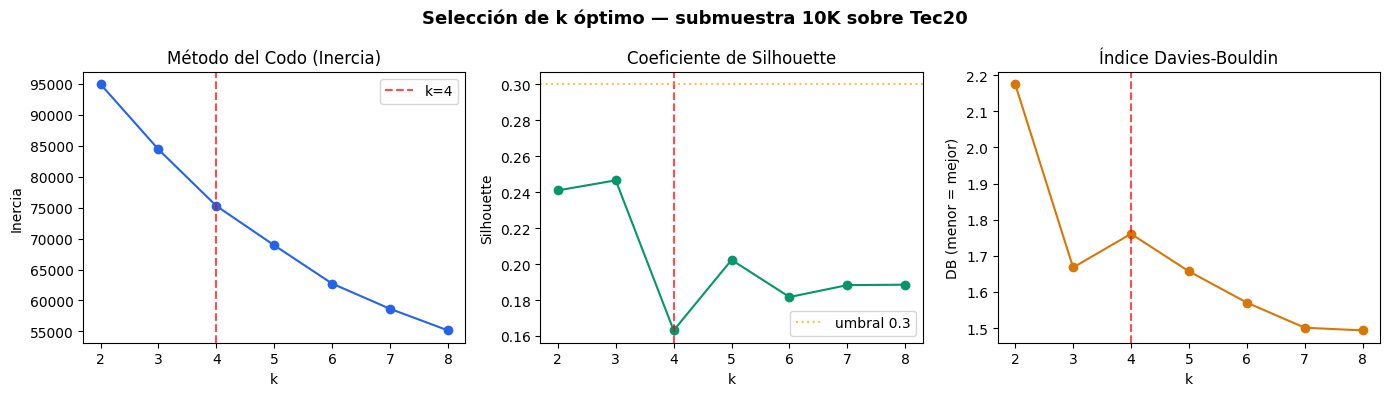


k=4 — Silhouette: 0.163 | Davies-Bouldin: 1.761

═══ Perfiles Tec20 ═══
             n  dropout_rate  pct_total
cluster                                
2        22542         0.119       42.5
3         2264         0.111        4.3
0        11398         0.071       21.5
1        16806         0.056       31.7


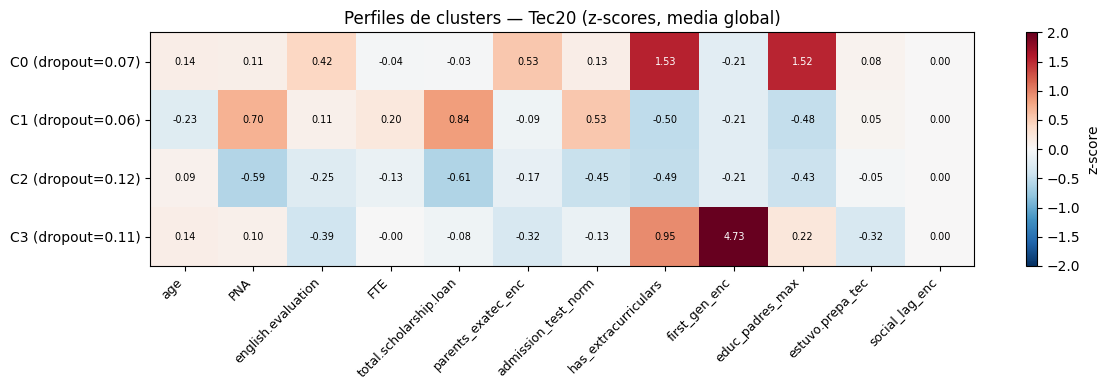


═══ Perfiles Tec21 (con centroides de Tec20) ═══
             n  dropout_rate  pct_total
cluster                                
2         2191         0.149        8.9
3         3129         0.129       12.8
1          808         0.083        3.3
0        18379         0.072       75.0

═══ Distribución comparativa Tec20 vs Tec21 ═══
         Tec20_%  Tec21_%  Tec20_dropout  Tec21_dropout  Δ_pct  Δ_dropout
cluster                                                                  
0           21.5     75.0          0.071          0.072   53.5      0.001
1           31.7      3.3          0.056          0.083  -28.4      0.027
2           42.5      8.9          0.119          0.149  -33.6      0.030
3            4.3     12.8          0.111          0.129    8.5      0.018


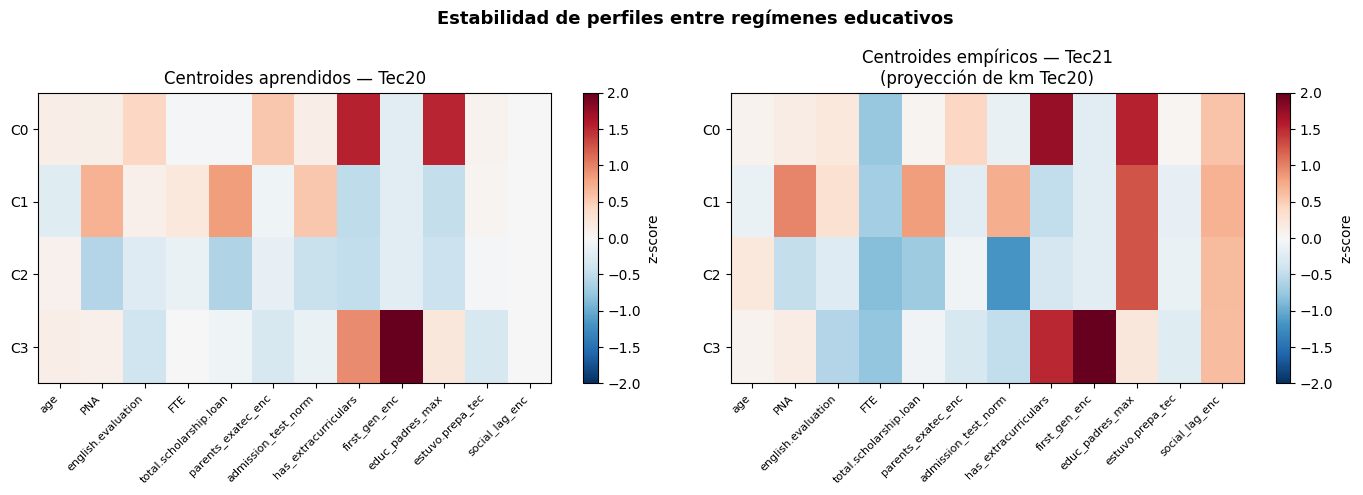


Diferencia absoluta de z-score (centroide Tec20 vs empírico Tec21):
      age    PNA  english.evaluation    FTE  total.scholarship.loan  parents_exatec_enc  admission_test_norm  has_extracurriculars  first_gen_enc  educ_padres_max  estuvo.prepa_tec  social_lag_enc
C0  0.063  0.041               0.205  0.714                   0.077               0.118                0.280                 0.219            0.0            0.011             0.042           0.570
C1  0.107  0.272               0.196  0.876                   0.001               0.118                0.190                 0.013            0.0            1.742             0.221           0.689
C2  0.128  0.104               0.010  0.719                   0.108               0.097                0.728                 0.155            0.0            1.693             0.083           0.638
C3  0.060  0.039               0.188  0.781                   0.018               0.002                0.366                 0.559            0

In [109]:
#METODO 1 APLICAR CLUSTERS DE TEC 20 A TEC 21
# ── 2.1a.1 Preparar datos de clustering ──────────────────────────────────────
X_clust_train_df = df.loc[tec20_mask, CLUSTER_COLS].copy()
X_clust_test_df  = df.loc[tec21_mask,  CLUSTER_COLS].copy()

# # Imputar con mediana del train (nunca del test)
# clust_medians = X_clust_train_df.median()
# X_clust_train_df.fillna(clust_medians, inplace=True)
# X_clust_test_df.fillna(clust_medians, inplace=True)

# Escalar con estadísticos del train
scaler_clust   = StandardScaler()
X_clust_train  = scaler_clust.fit_transform(X_clust_train_df)
X_clust_test   = scaler_clust.transform(X_clust_test_df)

print(f"\nTrain clustering shape: {X_clust_train.shape}")
print(f"Test  clustering shape: {X_clust_test.shape}")


# ── 2.1a.2 Selección de k óptimo (solo sobre Tec20) ──────────────────────────
inertias, silhouettes, db_scores = [], [], []
K_RANGE = range(2, 9)

rng     = np.random.default_rng(SEED)
idx_sub = rng.choice(len(X_clust_train),
                     size=min(10_000, len(X_clust_train)), replace=False)
X_sub   = X_clust_train[idx_sub]

for k in K_RANGE:
    km    = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    lbls  = km.fit_predict(X_sub)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sub, lbls,
                                        sample_size=3_000, random_state=SEED))
    db_scores.append(davies_bouldin_score(X_sub, lbls))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(list(K_RANGE), inertias,    'o-', color='#2563eb')
axes[0].set_title('Método del Codo (Inercia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[0].axvline(K_CLUSTERS, color='red', linestyle='--', alpha=0.7,
                label=f'k={K_CLUSTERS}'); axes[0].legend()

axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='#059669')
axes[1].set_title('Coeficiente de Silhouette')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].axvline(K_CLUSTERS, color='red', linestyle='--', alpha=0.7)
axes[1].axhline(0.3, color='orange', linestyle=':', alpha=0.7, label='umbral 0.3')
axes[1].legend()

axes[2].plot(list(K_RANGE), db_scores,   'o-', color='#d97706')
axes[2].set_title('Índice Davies-Bouldin')
axes[2].set_xlabel('k'); axes[2].set_ylabel('DB (menor = mejor)')
axes[2].axvline(K_CLUSTERS, color='red', linestyle='--', alpha=0.7)

plt.suptitle('Selección de k óptimo — submuestra 10K sobre Tec20',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\nk={K_CLUSTERS} — "
      f"Silhouette: {silhouettes[K_CLUSTERS-2]:.3f} | "
      f"Davies-Bouldin: {db_scores[K_CLUSTERS-2]:.3f}")


# ── 2.1a.3 Entrenar K-Means en Tec20 ─────────────────────────────────────────
km_final = KMeans(n_clusters=K_CLUSTERS, n_init=20, random_state=SEED)
km_final.fit(X_clust_train)          # entrena SOLO en Tec20

labels_train = km_final.labels_      # asignación Tec20

# DataFrames enriquecidos con columna cluster
df_train_profiles = df.loc[tec20_mask].copy()
df_train_profiles['cluster'] = labels_train

cluster_stats_train = (
    df_train_profiles
    .groupby('cluster')
    .agg(n=('retention', 'count'),
         dropout_rate=('retention', lambda x: (x == 0).mean()))
    .round(3)
)
cluster_stats_train['pct_total'] = (
    cluster_stats_train['n'] / len(df_train_profiles) * 100
).round(1)
cluster_stats_train = cluster_stats_train.sort_values('dropout_rate', ascending=False)

print("\n═══ Perfiles Tec20 ═══")
print(cluster_stats_train.to_string())

# Heatmap de centroides (z-scores respecto a media global del train)
centers_df = pd.DataFrame(km_final.cluster_centers_, columns=CLUSTER_COLS)
centers_df.index = [f'C{i}' for i in range(K_CLUSTERS)]

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(centers_df.values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks(range(len(CLUSTER_COLS)))
ax.set_xticklabels(CLUSTER_COLS, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(K_CLUSTERS))
ax.set_yticklabels(
    [f'C{i} (dropout={cluster_stats_train.loc[i, "dropout_rate"]:.2f})'
     for i in range(K_CLUSTERS)]
)
plt.colorbar(im, ax=ax, label='z-score')
ax.set_title('Perfiles de clusters — Tec20 (z-scores, media global)',
             fontsize=12)
for i in range(K_CLUSTERS):
    for j in range(len(CLUSTER_COLS)):
        v = centers_df.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(v) > 1.2 else 'black')
plt.tight_layout(); plt.show()


# ── 2.1a.4 Aplicar centroides Tec20 → Tec21 con predict ──────────────────────
# CLAVE: no se reentrena, se usa km_final.predict para proyectar Tec21
# sobre los perfiles aprendidos en Tec20.
labels_test = km_final.predict(X_clust_test)

df_test_profiles = df.loc[tec21_mask].copy()
df_test_profiles['cluster'] = labels_test

cluster_stats_test = (
    df_test_profiles
    .groupby('cluster')
    .agg(n=('retention', 'count'),
         dropout_rate=('retention', lambda x: (x == 0).mean()))
    .round(3)
)
cluster_stats_test['pct_total'] = (
    cluster_stats_test['n'] / len(df_test_profiles) * 100
).round(1)
cluster_stats_test = cluster_stats_test.sort_values('dropout_rate', ascending=False)

print("\n═══ Perfiles Tec21 (con centroides de Tec20) ═══")
print(cluster_stats_test.to_string())


# ── 2.1a.5 Comparación de distribución de clusters entre regímenes ────────────
print("\n═══ Distribución comparativa Tec20 vs Tec21 ═══")
comp = pd.DataFrame({
    'Tec20_%': cluster_stats_train['pct_total'],
    'Tec21_%': cluster_stats_test['pct_total'],
    'Tec20_dropout': cluster_stats_train['dropout_rate'],
    'Tec21_dropout': cluster_stats_test['dropout_rate'],
}).round(3)
comp['Δ_pct']     = (comp['Tec21_%']     - comp['Tec20_%']).round(1)
comp['Δ_dropout'] = (comp['Tec21_dropout'] - comp['Tec20_dropout']).round(3)
print(comp.to_string())

# Heatmap comparativo (mismos centroides, misma escala)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
centers = km_final.cluster_centers_   # centroides únicos (Tec20)

# Para Tec21 calculamos el centroide empírico de cada cluster en el espacio escalado
centers_test_empirical = np.array([
    X_clust_test[labels_test == k].mean(axis=0)
    for k in range(K_CLUSTERS)
])

for ax, data, title in [
    (axes[0], centers,                 'Centroides aprendidos — Tec20'),
    (axes[1], centers_test_empirical,  'Centroides empíricos — Tec21\n(proyección de km Tec20)')
]:
    im = ax.imshow(data, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
    ax.set_xticks(range(len(CLUSTER_COLS)))
    ax.set_xticklabels(CLUSTER_COLS, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(K_CLUSTERS))
    ax.set_yticklabels([f'C{i}' for i in range(K_CLUSTERS)])
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='z-score')

plt.suptitle('Estabilidad de perfiles entre regímenes educativos',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Diferencia absoluta entre centroide aprendido y empírico de Tec21
diff = np.abs(centers - centers_test_empirical)
diff_df = pd.DataFrame(diff, columns=CLUSTER_COLS,
                        index=[f'C{i}' for i in range(K_CLUSTERS)])
print("\nDiferencia absoluta de z-score (centroide Tec20 vs empírico Tec21):")
print(diff_df.round(3).to_string())
max_diff = diff_df.max(axis=0)
print(f"\nVariables con drift > 0.15:")
print(max_diff[max_diff > 0.15].sort_values(ascending=False).to_string())
invariant = (max_diff < 0.15).sum()
print(f"\n✓ Variables estables (Δz < 0.15): {invariant}/{len(CLUSTER_COLS)}")
print(f"✗ Variables con drift (Δz ≥ 0.15): {len(CLUSTER_COLS)-invariant}/{len(CLUSTER_COLS)}")


# ── 2.1a.6 Preparar datos para RF y Regresión Logística ──────────────────────
# Los clusters son la variable objetivo (y) para los modelos supervisados.
# X son las mismas FEATURE_COLS (sin tec_enc si se quiere evitar fuga de régimen).
# IMPORTANTE: los modelos supervisados se usan para EXPLICAR los perfiles,
# no para descubrirlos — la pregunta es "¿qué variables definen cada cluster?"

# Opcionalmente excluir tec_enc de FEATURE_COLS para evitar que el modelo
# aprenda régimen en vez de perfil:
FEATURE_COLS_RF = [c for c in FEATURE_COLS if c != 'tec_enc']

X_rf_lr_train = df_train_profiles[FEATURE_COLS_RF].values
y_rf_lr_train = df_train_profiles['cluster'].values   # etiqueta de perfil

X_rf_lr_test  = df_test_profiles[FEATURE_COLS_RF].values
y_rf_lr_test  = df_test_profiles['cluster'].values

# Imputar con el mismo imputer_final (ya ajustado en X_train sin tec_enc se recalcula)
imputer_rf = SimpleImputer(strategy='median')
X_rf_lr_train = imputer_rf.fit_transform(X_rf_lr_train)
X_rf_lr_test  = imputer_rf.transform(X_rf_lr_test)

print("\n═══ Datos listos para RF y Regresión Logística ═══")
print(f"X_rf_lr_train : {X_rf_lr_train.shape}  — features: {len(FEATURE_COLS_RF)}")
print(f"y_rf_lr_train : {y_rf_lr_train.shape}  — clusters: {np.unique(y_rf_lr_train)}")
print(f"X_rf_lr_test  : {X_rf_lr_test.shape}   — (Tec21 con etiquetas por proyección)")
print(f"y_rf_lr_test  : {y_rf_lr_test.shape}")
print(f"\nDistribución de clusters en train:")
for c, n in sorted(zip(*np.unique(y_rf_lr_train, return_counts=True))):
    print(f"  Cluster {c}: {n:>5,}  ({n/len(y_rf_lr_train)*100:.1f}%)")
print(f"\nDistribución de clusters en test (Tec21):")
for c, n in sorted(zip(*np.unique(y_rf_lr_test, return_counts=True))):
    print(f"  Cluster {c}: {n:>5,}  ({n/len(y_rf_lr_test)*100:.1f}%)")

# Checkpoints finales
print("\n─── Objetos disponibles para etapas siguientes ───")
print("  km_final          : KMeans entrenado en Tec20")
print("  scaler_clust      : StandardScaler del clustering")
print("  df_train_profiles : Tec20 + columna 'cluster'")
print("  df_test_profiles  : Tec21 + columna 'cluster' (proyectada)")
print("  X_rf_lr_train / y_rf_lr_train : Tec20 para RF/RL")
print("  X_rf_lr_test  / y_rf_lr_test  : Tec21 para RF/RL")
print("  FEATURE_COLS_RF   : features sin tec_enc")


In [110]:
# ============================================================
# GMM clustering para perfiles estudiantiles
# - Entrena en Tec20
# - Asigna Tec21 con el mismo modelo
# - Deja datos listos para RF / Regresión Logística
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score

Train (Tec20): 53,010 filas, 12 features
Test  (Tec21): 24,507 filas, 12 features


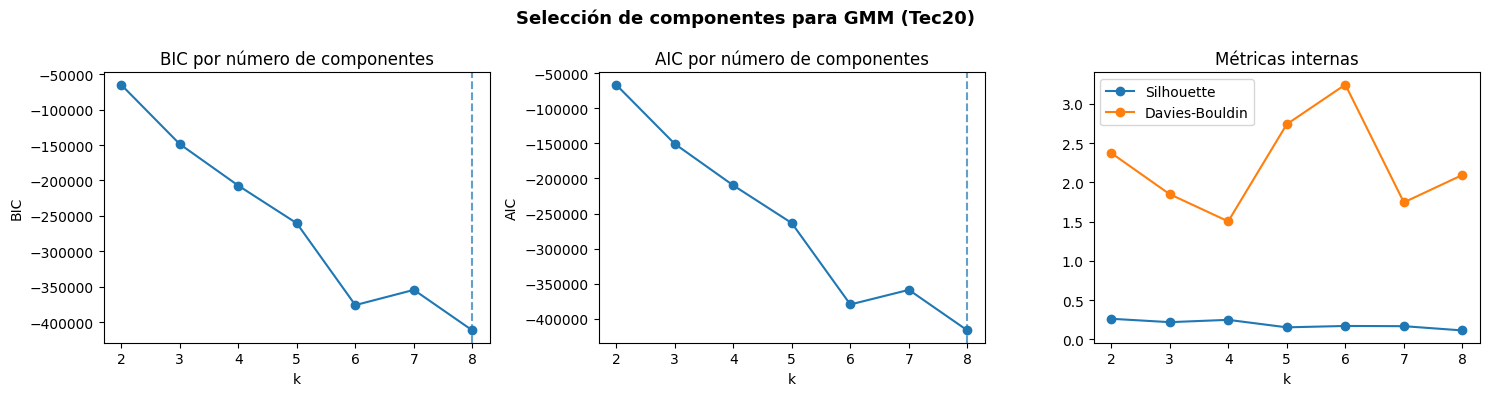

Mejor k por BIC: 8

Distribución de perfiles en Tec20:
cluster
0      164
1    10585
2     7184
3    10561
4     8837
5     5991
6     2191
7     7497
Name: count, dtype: int64

Distribución de perfiles en Tec21:
cluster
0      134
1     1702
2      707
3      806
4        2
5     4740
6     3068
7    13348
Name: count, dtype: int64

═══ Perfiles Tec20 ═══
             n  dropout_rate  %_total
cluster                              
0          164         0.268      0.3
1        10585         0.089     20.0
2         7184         0.087     13.6
3        10561         0.068     19.9
4         8837         0.141     16.7
5         5991         0.052     11.3
6         2191         0.113      4.1
7         7497         0.074     14.1

Promedios por cluster en Tec20:
            age     PNA  english.evaluation    FTE  total.scholarship.loan  parents_exatec_enc  admission_test_norm  has_extracurriculars  first_gen_enc  educ_padres_max  estuvo.prepa_tec  social_lag_enc
cluster                 

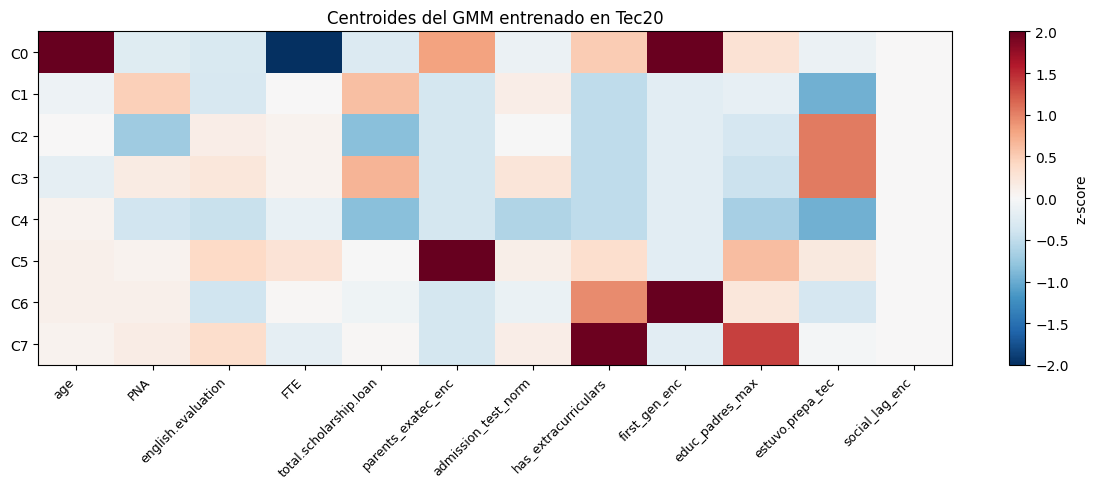


Cambio absoluto promedio por cluster (Tec21 vs Tec20):
      age    PNA  english.evaluation    FTE  total.scholarship.loan  parents_exatec_enc  admission_test_norm  has_extracurriculars  first_gen_enc  educ_padres_max  estuvo.prepa_tec  social_lag_enc
C0  1.023  0.624               0.368  0.109                   0.039               0.098                0.040                 0.369           0.01            0.663             0.004           0.567
C1  0.196  1.604               0.088  0.102                   0.235               0.000                0.045                 0.000           0.00            1.820             0.000           0.626
C2  0.202  0.075               0.692  0.119                   0.000               0.000                0.000                 0.000           0.00            2.015             0.000           0.636
C3  0.236  0.295               1.027  0.111                   0.151               0.000                0.034                 0.000           0.00           

In [111]:


# ------------------------------------------------------------
# 0) Configuración
# ------------------------------------------------------------
SEED = 42
np.random.seed(SEED)

# Ajusta estas listas a tu proyecto
# TRAIN_GENS = [...]
# TEST_GENS  = [...]
# TARGET = 'retention'   # si existe en tu df


# ------------------------------------------------------------
# 1) Split temporal / por generación
# ------------------------------------------------------------
train_mask = df['generation'].isin(TRAIN_GENS)   # Tec20
test_mask  = df['generation'].isin(TEST_GENS)    # Tec21

df_train = df.loc[train_mask].copy()
df_test  = df.loc[test_mask].copy()

X_train_raw = df_train[FEATURE_COLS].copy()
X_test_raw  = df_test[FEATURE_COLS].copy()

print(f"Train (Tec20): {X_train_raw.shape[0]:,} filas, {X_train_raw.shape[1]} features")
print(f"Test  (Tec21): {X_test_raw.shape[0]:,} filas, {X_test_raw.shape[1]} features")

# ------------------------------------------------------------
# 2) Imputación + escalamiento
#    Importante: fit solo con Tec20
# ------------------------------------------------------------
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_raw),
    columns=FEATURE_COLS,
    index=X_train_raw.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test_raw),
    columns=FEATURE_COLS,
    index=X_test_raw.index
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_imp)
X_test  = scaler.transform(X_test_imp)

# ------------------------------------------------------------
# 3) Selección de número de componentes con BIC / AIC
#    (GMM no usa elbow; aquí el criterio más útil es BIC)
# ------------------------------------------------------------
K_RANGE = range(2, 9)

bics = []
aics = []
silhouettes = []
db_scores = []

# Submuestra para acelerar si el dataset es grande
rng = np.random.default_rng(SEED)
n_sub = min(10000, len(X_train))
idx_sub = rng.choice(len(X_train), size=n_sub, replace=False)
X_sub = X_train[idx_sub]

for k in K_RANGE:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=SEED,
        n_init=5,
        reg_covar=1e-6
    )
    gmm.fit(X_sub)

    labels_sub = gmm.predict(X_sub)

    bics.append(gmm.bic(X_sub))
    aics.append(gmm.aic(X_sub))

    # Silhouette solo si hay más de 1 cluster efectivo
    try:
        silhouettes.append(silhouette_score(X_sub, labels_sub))
    except Exception:
        silhouettes.append(np.nan)

    try:
        db_scores.append(davies_bouldin_score(X_sub, labels_sub))
    except Exception:
        db_scores.append(np.nan)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(list(K_RANGE), bics, marker='o')
axes[0].set_title('BIC por número de componentes')
axes[0].set_xlabel('k')
axes[0].set_ylabel('BIC')
axes[0].axvline(list(K_RANGE)[int(np.argmin(bics))], linestyle='--', alpha=0.7)

axes[1].plot(list(K_RANGE), aics, marker='o')
axes[1].set_title('AIC por número de componentes')
axes[1].set_xlabel('k')
axes[1].set_ylabel('AIC')
axes[1].axvline(list(K_RANGE)[int(np.argmin(aics))], linestyle='--', alpha=0.7)

axes[2].plot(list(K_RANGE), silhouettes, marker='o', label='Silhouette')
axes[2].plot(list(K_RANGE), db_scores, marker='o', label='Davies-Bouldin')
axes[2].set_title('Métricas internas')
axes[2].set_xlabel('k')
axes[2].legend()

plt.suptitle('Selección de componentes para GMM (Tec20)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = list(K_RANGE)[int(np.argmin(bics))]
print(f"Mejor k por BIC: {best_k}")

# ------------------------------------------------------------
# 4) Entrenar GMM final en Tec20
# ------------------------------------------------------------
gmm = GaussianMixture(
    n_components=best_k,
    covariance_type='full',
    random_state=SEED,
    n_init=10,
    reg_covar=1e-6
)
gmm.fit(X_train)

# Asignación de clusters / perfiles
train_clusters = gmm.predict(X_train)
test_clusters  = gmm.predict(X_test)

# Probabilidades de pertenencia
train_proba = gmm.predict_proba(X_train)
test_proba  = gmm.predict_proba(X_test)

train_max_proba = train_proba.max(axis=1)
test_max_proba  = test_proba.max(axis=1)

# ------------------------------------------------------------
# 5) Guardar perfiles en dataframes
# ------------------------------------------------------------
df_train_profiles = df_train.copy()
df_test_profiles  = df_test.copy()

df_train_profiles['cluster'] = train_clusters
df_test_profiles['cluster']  = test_clusters

df_train_profiles['cluster_prob'] = train_max_proba
df_test_profiles['cluster_prob']  = test_max_proba

df_train_profiles['split'] = 'Tec20'
df_test_profiles['split']  = 'Tec21'

# Dataset combinado
df_profiles = pd.concat([df_train_profiles, df_test_profiles], axis=0).reset_index(drop=True)

print("\nDistribución de perfiles en Tec20:")
print(df_train_profiles['cluster'].value_counts().sort_index())

print("\nDistribución de perfiles en Tec21:")
print(df_test_profiles['cluster'].value_counts().sort_index())

# ------------------------------------------------------------
# 6) Resumen por cluster
# ------------------------------------------------------------
if 'retention' in df_train_profiles.columns:
    cluster_stats_train = df_train_profiles.groupby('cluster').agg(
        n=('retention', 'count'),
        dropout_rate=('retention', lambda x: (x == 0).mean())
    ).round(3)
    cluster_stats_train['%_total'] = (cluster_stats_train['n'] / len(df_train_profiles) * 100).round(1)

    print("\n═══ Perfiles Tec20 ═══")
    print(cluster_stats_train.to_string())

# ------------------------------------------------------------
# 7) Interpretación: medias originales por cluster
# ------------------------------------------------------------
cluster_profile_means_train = (
    df_train_profiles.groupby('cluster')[FEATURE_COLS]
    .mean(numeric_only=True)
    .round(3)
)

cluster_profile_means_test = (
    df_test_profiles.groupby('cluster')[FEATURE_COLS]
    .mean(numeric_only=True)
    .round(3)
)

print("\nPromedios por cluster en Tec20:")
print(cluster_profile_means_train.to_string())

print("\nPromedios por cluster en Tec21:")
print(cluster_profile_means_test.to_string())

# ------------------------------------------------------------
# 8) Visualización de perfiles en z-score
# ------------------------------------------------------------
gmm_centers_scaled = pd.DataFrame(gmm.means_, columns=FEATURE_COLS)
gmm_centers_scaled.index = [f'C{i}' for i in range(best_k)]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(gmm_centers_scaled.values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(best_k))
ax.set_yticklabels([f'C{i}' for i in range(best_k)])
plt.colorbar(im, ax=ax, label='z-score')
ax.set_title('Centroides del GMM entrenado en Tec20')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9) Comparación de estabilidad entre Tec20 y Tec21
#    Métrica útil: comparar el perfil promedio por cluster
#    y, si quieres, luego hacer Spearman en importancias.
# ------------------------------------------------------------
# Si quieres comparar perfiles globales entre generaciones:
profile_shift = {}
common_clusters = sorted(set(df_train_profiles['cluster'].unique()).intersection(df_test_profiles['cluster'].unique()))

for c in common_clusters:
    mean_train = df_train_profiles.loc[df_train_profiles['cluster'] == c, FEATURE_COLS].mean(numeric_only=True)
    mean_test  = df_test_profiles.loc[df_test_profiles['cluster'] == c, FEATURE_COLS].mean(numeric_only=True)
    profile_shift[c] = (mean_test - mean_train).abs()

profile_shift_df = pd.DataFrame(profile_shift).T
profile_shift_df.index = [f'C{c}' for c in profile_shift_df.index]

print("\nCambio absoluto promedio por cluster (Tec21 vs Tec20):")
print(profile_shift_df.round(3).to_string())

# ------------------------------------------------------------
# 10) Dataset listo para RF / Regresión Logística
#     Aquí el target será el cluster asignado por GMM
# ------------------------------------------------------------
X_rf_lr_train = df_train_profiles[FEATURE_COLS].copy()
y_rf_lr_train = df_train_profiles['cluster'].copy()

X_rf_lr_test = df_test_profiles[FEATURE_COLS].copy()
y_rf_lr_test = df_test_profiles['cluster'].copy()

print("\nListo para RF / RL:")
print("X_rf_lr_train:", X_rf_lr_train.shape)
print("y_rf_lr_train:", y_rf_lr_train.shape)
print("X_rf_lr_test :", X_rf_lr_test.shape)
print("y_rf_lr_test :", y_rf_lr_test.shape)

Train Tec20: (53010, 12)
Test  Tec21: (24507, 12)
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.43s/it, max_LL=-1.32e+5, max_avg_LL=-2.5]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.32s/it, max_LL=2.43e+5, max_avg_LL=4.58]


Fitting StepMix...


...

Initializations (n_init) : 100%|██████████| 1/1 [00:06<00:00,  6.41s/it, max_LL=5.8e+5, max_avg_LL=10.9]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:08<00:00,  8.28s/it, max_LL=8.14e+5, max_avg_LL=15.4]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:10<00:00, 10.54s/it, max_LL=4.87e+5, max_avg_LL=9.19]


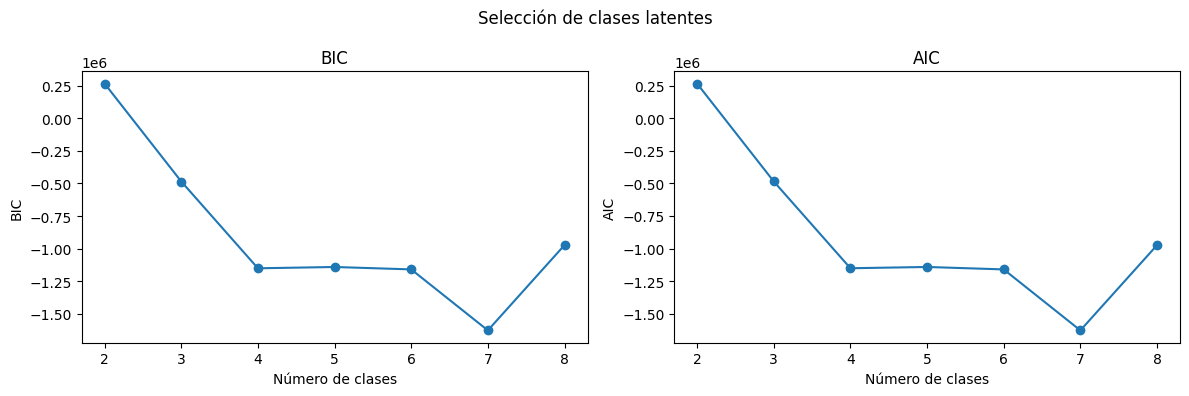


Mejor número de clases según BIC: 7
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:05<00:00,  5.62s/it, max_LL=8.14e+5, max_avg_LL=15.4]



Distribución Tec20
cluster
0    0.001415
1    0.006093
2    0.602226
3    0.141068
4    0.041294
5    0.109055
6    0.098849
Name: proportion, dtype: float64

Distribución Tec21
cluster
0    0.002652
1    0.026237
2    0.000326
3    0.543355
4    0.125026
5    0.171339
6    0.131065
Name: proportion, dtype: float64

═══ Perfiles Tec20 ═══
            age     PNA  english.evaluation    FTE  total.scholarship.loan  parents_exatec_enc  admission_test_norm  has_extracurriculars  first_gen_enc  educ_padres_max  estuvo.prepa_tec  social_lag_enc
cluster                                                                                                                                                                                                    
0        19.293  87.077               4.973  0.997                   0.221               0.400                0.802                 0.560            1.0           -0.227             0.480             0.0
1        20.799  85.244               1.920  0

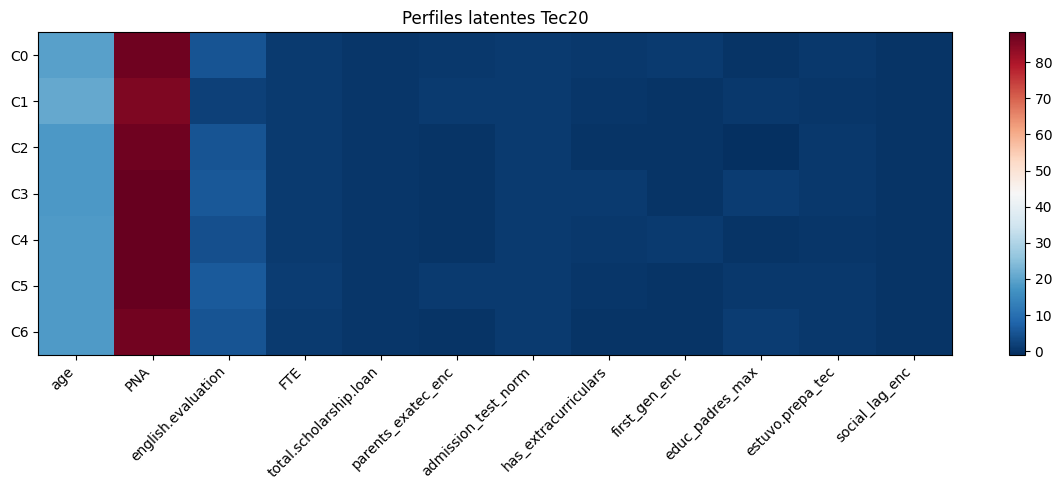


Cambio absoluto promedio Tec21 vs Tec20
           age    PNA  english.evaluation    FTE  total.scholarship.loan  parents_exatec_enc  admission_test_norm  has_extracurriculars  first_gen_enc  educ_padres_max  estuvo.prepa_tec  social_lag_enc
cluster                                                                                                                                                                                                  
0        2.845  0.085               0.242  0.030                   0.037               0.262                0.040                 0.209            0.0            0.227             0.012           0.492
1        2.035  2.588               0.133  0.040                   0.061               0.126                0.029                 0.401            0.0            1.003             0.004           0.611
2        0.659  3.113               0.990  0.108                   0.213               0.000                0.038                 0.000            0.0 

In [112]:

# ============================================================
# LATENT CLASS ANALYSIS (LCA)
# Perfiles estudiantiles Tec20 -> Tec21
# ============================================================

# Requiere:
# pip install stepmix

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from stepmix.stepmix import StepMix

# ============================================================
# 0) CONFIGURACIÓN
# ============================================================

SEED = 42
np.random.seed(SEED)


# ============================================================
# 1) SPLIT TEMPORAL
# ============================================================

train_mask = df['generation'].isin(TRAIN_GENS)   # Tec20
test_mask  = df['generation'].isin(TEST_GENS)    # Tec21

df_train = df.loc[train_mask].copy()
df_test  = df.loc[test_mask].copy()

X_train_raw = df_train[FEATURE_COLS].copy()
X_test_raw  = df_test[FEATURE_COLS].copy()

print(f"Train Tec20: {X_train_raw.shape}")
print(f"Test  Tec21: {X_test_raw.shape}")

# ============================================================
# 2) IMPUTACIÓN
# ============================================================

imputer = SimpleImputer(strategy='median')

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_raw),
    columns=FEATURE_COLS,
    index=X_train_raw.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test_raw),
    columns=FEATURE_COLS,
    index=X_test_raw.index
)

# ============================================================
# 3) ESCALAMIENTO
# ============================================================

# Aunque LCA clásico trabaja mejor con categóricas,
# StepMix maneja gaussianas también.

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_imp)
X_test  = scaler.transform(X_test_imp)

# ============================================================
# 4) SELECCIÓN DE NÚMERO DE CLASES
# ============================================================

K_RANGE = range(2, 9)

bic_scores = []
aic_scores = []

for k in K_RANGE:

    model = StepMix(
        n_components=k,
        measurement='continuous',
        random_state=SEED,
        verbose=0
    )

    model.fit(X_train)

    bic_scores.append(model.bic(X_train))
    aic_scores.append(model.aic(X_train))

# ============================================================
# 5) VISUALIZACIÓN BIC / AIC
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_RANGE), bic_scores, marker='o')
axes[0].set_title('BIC')
axes[0].set_xlabel('Número de clases')
axes[0].set_ylabel('BIC')

axes[1].plot(list(K_RANGE), aic_scores, marker='o')
axes[1].set_title('AIC')
axes[1].set_xlabel('Número de clases')
axes[1].set_ylabel('AIC')

plt.suptitle('Selección de clases latentes')
plt.tight_layout()
plt.show()

best_k = list(K_RANGE)[np.argmin(bic_scores)]

print(f"\nMejor número de clases según BIC: {best_k}")

# ============================================================
# 6) ENTRENAR MODELO FINAL LCA
# ============================================================

lca_model = StepMix(
    n_components=best_k,
    measurement='continuous',
    random_state=SEED,
    verbose=0
)

lca_model.fit(X_train)

# ============================================================
# 7) ASIGNACIÓN DE CLASES
# ============================================================

train_clusters = lca_model.predict(X_train)
test_clusters  = lca_model.predict(X_test)

# ============================================================
# 8) PROBABILIDADES DE PERTENENCIA
# ============================================================

train_proba = lca_model.predict_proba(X_train)
test_proba  = lca_model.predict_proba(X_test)

train_max_proba = train_proba.max(axis=1)
test_max_proba  = test_proba.max(axis=1)

# ============================================================
# 9) GUARDAR RESULTADOS
# ============================================================

df_train_profiles = df_train.copy()
df_test_profiles  = df_test.copy()

df_train_profiles['cluster'] = train_clusters
df_test_profiles['cluster']  = test_clusters

df_train_profiles['cluster_prob'] = train_max_proba
df_test_profiles['cluster_prob']  = test_max_proba

df_train_profiles['split'] = 'Tec20'
df_test_profiles['split']  = 'Tec21'

df_profiles = pd.concat(
    [df_train_profiles, df_test_profiles],
    axis=0
).reset_index(drop=True)

# ============================================================
# 10) DISTRIBUCIÓN DE CLASES
# ============================================================

print("\nDistribución Tec20")
print(
    df_train_profiles['cluster']
    .value_counts(normalize=True)
    .sort_index()
)

print("\nDistribución Tec21")
print(
    df_test_profiles['cluster']
    .value_counts(normalize=True)
    .sort_index()
)

# ============================================================
# 11) RESUMEN POR CLASE LATENTE
# ============================================================

cluster_summary_train = (
    df_train_profiles
    .groupby('cluster')[FEATURE_COLS]
    .mean()
    .round(3)
)

cluster_summary_test = (
    df_test_profiles
    .groupby('cluster')[FEATURE_COLS]
    .mean()
    .round(3)
)

print("\n═══ Perfiles Tec20 ═══")
print(cluster_summary_train.to_string())

print("\n═══ Perfiles Tec21 ═══")
print(cluster_summary_test.to_string())

# ============================================================
# 12) HEATMAP DE PERFILES
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(
    cluster_summary_train.values,
    cmap='RdBu_r',
    aspect='auto'
)

ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(
    FEATURE_COLS,
    rotation=45,
    ha='right'
)

ax.set_yticks(range(best_k))
ax.set_yticklabels([f'C{i}' for i in range(best_k)])

plt.colorbar(im, ax=ax)

ax.set_title('Perfiles latentes Tec20')

plt.tight_layout()
plt.show()

# ============================================================
# 13) ESTABILIDAD ENTRE TEC20 Y TEC21
# ============================================================

profile_shift = (
    cluster_summary_test - cluster_summary_train
).abs()

print("\nCambio absoluto promedio Tec21 vs Tec20")
print(profile_shift.round(3).to_string())

# ============================================================
# 14) DATASETS LISTOS PARA RF / RL
# ============================================================

X_rf_lr_train = df_train_profiles[FEATURE_COLS].copy()
y_rf_lr_train = df_train_profiles['cluster'].copy()

X_rf_lr_test = df_test_profiles[FEATURE_COLS].copy()
y_rf_lr_test = df_test_profiles['cluster'].copy()

print("\nDatasets listos para RF / RL")

print("X_rf_lr_train:", X_rf_lr_train.shape)
print("y_rf_lr_train:", y_rf_lr_train.shape)

print("X_rf_lr_test :", X_rf_lr_test.shape)
print("y_rf_lr_test :", y_rf_lr_test.shape)

# ============================================================
# 15) MATRIZ DE PROBABILIDADES (OPCIONAL)
# ============================================================

cluster_prob_cols = [
    f'prob_cluster_{i}'
    for i in range(best_k)
]

train_prob_df = pd.DataFrame(
    train_proba,
    columns=cluster_prob_cols,
    index=df_train_profiles.index
)

test_prob_df = pd.DataFrame(
    test_proba,
    columns=cluster_prob_cols,
    index=df_test_profiles.index
)

print("\nProbabilidades de pertenencia disponibles")
print(train_prob_df.head())


In [113]:
# # ============================================================
# # SPECTRAL CLUSTERING
# # Perfiles estudiantiles Tec20 -> Tec21
# # ============================================================

# # IMPORTANTE:
# # Spectral Clustering NO tiene predict() natural.
# # Entonces:
# # 1. Se entrena en Tec20
# # 2. Se obtienen embeddings espectrales
# # 3. Se entrena un clasificador KNN
# # 4. KNN asigna clusters a Tec21
# #
# # Esto permite mantener:
# # - perfiles aprendidos en Tec20
# # - transferencia hacia Tec21
# # ============================================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler

# from sklearn.cluster import SpectralClustering
# from sklearn.manifold import SpectralEmbedding

# from sklearn.neighbors import KNeighborsClassifier

# from sklearn.metrics import (
#     silhouette_score,
#     davies_bouldin_score
# )

# # ============================================================
# # 0) CONFIGURACIÓN
# # ============================================================

# SEED = 42
# np.random.seed(SEED)


# # ============================================================
# # 1) SPLIT
# # ============================================================

# train_mask = df['generation'].isin(TRAIN_GENS)
# test_mask  = df['generation'].isin(TEST_GENS)

# df_train = df.loc[train_mask].copy()
# df_test  = df.loc[test_mask].copy()

# X_train_raw = df_train[FEATURE_COLS].copy()
# X_test_raw  = df_test[FEATURE_COLS].copy()

# print(f"Train Tec20: {X_train_raw.shape}")
# print(f"Test  Tec21: {X_test_raw.shape}")

# # ============================================================
# # 2) IMPUTACIÓN
# # ============================================================

# imputer = SimpleImputer(strategy='median')

# X_train_imp = pd.DataFrame(
#     imputer.fit_transform(X_train_raw),
#     columns=FEATURE_COLS,
#     index=X_train_raw.index
# )

# X_test_imp = pd.DataFrame(
#     imputer.transform(X_test_raw),
#     columns=FEATURE_COLS,
#     index=X_test_raw.index
# )

# # ============================================================
# # 3) ESCALAMIENTO
# # ============================================================

# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train_imp)
# X_test  = scaler.transform(X_test_imp)

# # ============================================================
# # 4) SELECCIÓN DE k
# # ============================================================

# K_RANGE = range(2, 9)

# sil_scores = []
# db_scores = []

# # Submuestra para acelerar
# rng = np.random.default_rng(SEED)

# idx_sub = rng.choice(
#     len(X_train),
#     size=min(10000, len(X_train)),
#     replace=False
# )

# X_sub = X_train[idx_sub]

# for k in K_RANGE:

#     spectral = SpectralClustering(
#         n_clusters=k,
#         affinity='nearest_neighbors',
#         n_neighbors=15,
#         assign_labels='kmeans',
#         random_state=SEED
#     )

#     labels = spectral.fit_predict(X_sub)

#     sil = silhouette_score(X_sub, labels)
#     db  = davies_bouldin_score(X_sub, labels)

#     sil_scores.append(sil)
#     db_scores.append(db)

# # ============================================================
# # 5) VISUALIZACIÓN MÉTRICAS
# # ============================================================

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# axes[0].plot(list(K_RANGE), sil_scores, marker='o')
# axes[0].set_title('Silhouette')
# axes[0].set_xlabel('k')

# axes[1].plot(list(K_RANGE), db_scores, marker='o')
# axes[1].set_title('Davies-Bouldin')
# axes[1].set_xlabel('k')

# plt.suptitle('Selección de k - Spectral Clustering')
# plt.tight_layout()
# plt.show()

# best_k = list(K_RANGE)[np.argmax(sil_scores)]

# print(f"\nMejor k según silhouette: {best_k}")

# # ============================================================
# # 6) EMBEDDING ESPECTRAL
# # ============================================================

# embedding = SpectralEmbedding(
#     n_components=best_k,
#     affinity='nearest_neighbors',
#     n_neighbors=15,
#     random_state=SEED
# )

# X_train_embed = embedding.fit_transform(X_train)

# # ============================================================
# # 7) CLUSTERING FINAL EN TEC20
# # ============================================================

# spectral_final = SpectralClustering(
#     n_clusters=best_k,
#     affinity='nearest_neighbors',
#     n_neighbors=15,
#     assign_labels='kmeans',
#     random_state=SEED
# )

# train_clusters = spectral_final.fit_predict(X_train)

# # ============================================================
# # 8) TRANSFERENCIA A TEC21
# # ============================================================

# # Spectral NO tiene predict().
# # Entonces usamos KNN sobre el espacio original.

# knn = KNeighborsClassifier(n_neighbors=15)

# knn.fit(X_train, train_clusters)

# test_clusters = knn.predict(X_test)

# # ============================================================
# # 9) PROBABILIDADES
# # ============================================================

# train_proba = knn.predict_proba(X_train)
# test_proba  = knn.predict_proba(X_test)

# train_max_proba = train_proba.max(axis=1)
# test_max_proba  = test_proba.max(axis=1)

# # ============================================================
# # 10) GUARDAR RESULTADOS
# # ============================================================

# df_train_profiles = df_train.copy()
# df_test_profiles  = df_test.copy()

# df_train_profiles['cluster'] = train_clusters
# df_test_profiles['cluster']  = test_clusters

# df_train_profiles['cluster_prob'] = train_max_proba
# df_test_profiles['cluster_prob']  = test_max_proba

# df_train_profiles['split'] = 'Tec20'
# df_test_profiles['split']  = 'Tec21'

# df_profiles = pd.concat(
#     [df_train_profiles, df_test_profiles],
#     axis=0
# ).reset_index(drop=True)

# # ============================================================
# # 11) DISTRIBUCIÓN DE CLUSTERS
# # ============================================================

# print("\nDistribución Tec20")
# print(
#     df_train_profiles['cluster']
#     .value_counts(normalize=True)
#     .sort_index()
# )

# print("\nDistribución Tec21")
# print(
#     df_test_profiles['cluster']
#     .value_counts(normalize=True)
#     .sort_index()
# )

# # ============================================================
# # 12) RESUMEN DE PERFILES
# # ============================================================

# cluster_summary_train = (
#     df_train_profiles
#     .groupby('cluster')[FEATURE_COLS]
#     .mean()
#     .round(3)
# )

# cluster_summary_test = (
#     df_test_profiles
#     .groupby('cluster')[FEATURE_COLS]
#     .mean()
#     .round(3)
# )

# print("\n═══ Perfiles Tec20 ═══")
# print(cluster_summary_train.to_string())

# print("\n═══ Perfiles Tec21 ═══")
# print(cluster_summary_test.to_string())

# # ============================================================
# # 13) HEATMAP
# # ============================================================

# fig, ax = plt.subplots(figsize=(12, 5))

# im = ax.imshow(
#     cluster_summary_train.values,
#     cmap='RdBu_r',
#     aspect='auto'
# )

# ax.set_xticks(range(len(FEATURE_COLS)))
# ax.set_xticklabels(
#     FEATURE_COLS,
#     rotation=45,
#     ha='right'
# )

# ax.set_yticks(range(best_k))
# ax.set_yticklabels([f'C{i}' for i in range(best_k)])

# plt.colorbar(im, ax=ax)

# ax.set_title('Perfiles Spectral Clustering - Tec20')

# plt.tight_layout()
# plt.show()

# # ============================================================
# # 14) ESTABILIDAD ENTRE TEC20 Y TEC21
# # ============================================================

# profile_shift = (
#     cluster_summary_test - cluster_summary_train
# ).abs()

# print("\nCambio absoluto promedio Tec21 vs Tec20")
# print(profile_shift.round(3).to_string())

# # ============================================================
# # 15) VISUALIZACIÓN 2D DEL EMBEDDING
# # ============================================================

# embed_2d = SpectralEmbedding(
#     n_components=2,
#     affinity='nearest_neighbors',
#     n_neighbors=15,
#     random_state=SEED
# )

# X_2d = embed_2d.fit_transform(X_train)

# plt.figure(figsize=(7, 6))

# scatter = plt.scatter(
#     X_2d[:, 0],
#     X_2d[:, 1],
#     c=train_clusters,
#     s=8,
#     alpha=0.7
# )

# plt.title('Embedding espectral 2D - Tec20')
# plt.xlabel('Component 1')
# plt.ylabel('Component 2')

# plt.show()

# # ============================================================
# # 16) DATASETS LISTOS PARA RF / RL
# # ============================================================

# X_rf_lr_train = df_train_profiles[FEATURE_COLS].copy()
# y_rf_lr_train = df_train_profiles['cluster'].copy()

# X_rf_lr_test = df_test_profiles[FEATURE_COLS].copy()
# y_rf_lr_test = df_test_profiles['cluster'].copy()

# print("\nDatasets listos para RF / RL")

# print("X_rf_lr_train:", X_rf_lr_train.shape)
# print("y_rf_lr_train:", y_rf_lr_train.shape)

# print("X_rf_lr_test :", X_rf_lr_test.shape)
# print("y_rf_lr_test :", y_rf_lr_test.shape)